In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
import nltk
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm import tqdm
from PIL import Image

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
os.makedirs("results", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

In [ ]:
data = []
with open('captions.txt') as f:
  next(f)
  for line in f:
    img, cap = line.strip().split(',', 1)
    data.append((img,cap.lower()))

all_imgs = sorted(set(img for img, _ in data))
train_imgs, test_imgs = train_test_split(all_imgs, test_size=0.2, random_state=42)
train_imgs, test_imgs = set(train_imgs), set(test_imgs)

train_data = [(i, c) for i, c in data if i in train_imgs]
test_data = [(i, c) for i, c in data if i in test_imgs]

In [ ]:
class ImageTextDataset(Dataset):
    def __init__(self, image_dir, data, transform, max_len=40, vocab=None):
        self.image_dir, self.data, self.transform, self.max_len = image_dir, data, transform, max_len
        if vocab is None:
            vocab_set = sorted(set(t for _, c in data for t in word_tokenize(c)))
            self.word2idx = {w: i+2 for i, w in enumerate(vocab_set)}
            self.word2idx["<pad>"] = 0
            self.word2idx["<unk>"] = 1
        else:
            self.word2idx = vocab

    def encode(self, caption):
        ids = [self.word2idx.get(t, 1) for t in word_tokenize(caption)][:self.max_len]
        return torch.tensor(ids + [0] * (self.max_len - len(ids)))

    def __len__(self):
      return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        image = Image.open(os.path.join(self.image_dir, img_name)).convert("RGB")
        return self.transform(image), self.encode(caption), caption, img_name

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageTextDataset("Images", train_data, transform)
test_dataset  = ImageTextDataset("Images", test_data, transform, vocab=train_dataset.word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [6]:
class ImageEncoder(nn.Module):
    def __init__(self, EMBED_DIM):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.fc = nn.Linear(512, EMBED_DIM)

    def forward(self, x):
        return F.normalize(self.fc(self.features(x).flatten(1)), dim=1)

class TextEncoder(nn.Module):
    def __init__(self, vocab_size, EMBED_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 300, padding_idx=0)
        self.gru = nn.GRU(300, EMBED_DIM, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(EMBED_DIM * 2, 1)
        self.fc = nn.Linear(EMBED_DIM * 2, EMBED_DIM)

    def forward(self, x):
        outputs, _ = self.gru(self.embedding(x))
        attn_weights = torch.softmax(self.attn(outputs), dim=1)
        context = (attn_weights * outputs).sum(dim=1)
        return F.normalize(self.fc(context), dim=1)

def contrastive_loss(img_emb, txt_emb, temperature=0.07):
    logits = img_emb @ txt_emb.T / temperature
    labels = torch.arange(len(logits), device=logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]
Epoch 1: 100%|██████████| 1012/1012 [03:23<00:00,  4.98it/s]


Epoch 1 Loss = 1.5803


Epoch 2: 100%|██████████| 1012/1012 [03:13<00:00,  5.24it/s]


Epoch 2 Loss = 0.5699


...

Epoch 8 Loss = 0.1178


Epoch 9: 100%|██████████| 1012/1012 [03:04<00:00,  5.48it/s]


Epoch 9 Loss = 0.1090


Epoch 10: 100%|██████████| 1012/1012 [03:05<00:00,  5.44it/s]


Epoch 10 Loss = 0.0979


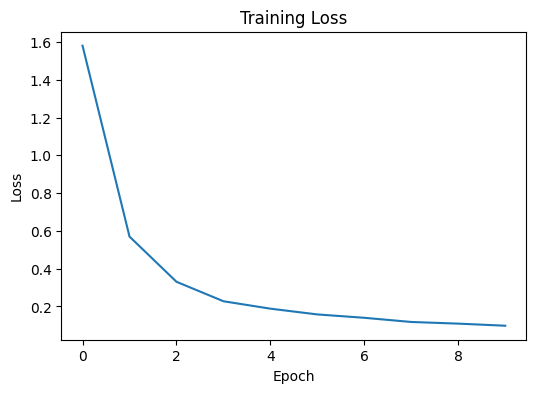

In [7]:
EMBED_DIM = 256
image_encoder = ImageEncoder(EMBED_DIM).to(device)
text_encoder  = TextEncoder(len(train_dataset.word2idx), EMBED_DIM).to(device)

optimizer = torch.optim.Adam(
    list(image_encoder.parameters()) + list(text_encoder.parameters()), lr=1e-4
)

train_losses = []
for epoch in range(10):
    image_encoder.train()
    text_encoder.train()
    total_loss = 0
    for imgs, caps, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, caps = imgs.to(device), caps.to(device)
        optimizer.zero_grad()
        loss = contrastive_loss(image_encoder(imgs), text_encoder(caps))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    epoch_loss=total_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1} Loss = {epoch_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.savefig("results/03_loss_curve.png")
plt.show()

In [8]:
torch.save({
    "image_encoder": image_encoder.state_dict(),
    "text_encoder": text_encoder.state_dict(),
    "optimizer": optimizer.state_dict(),
    "epoch_completed": len(train_losses),
    "train_losses": train_losses,
    "vocab": train_dataset.word2idx,
    "config": {
        "embed_dim": EMBED_DIM,
        "lr": 1e-4,
        "batch_size": 32,
        "max_len": 40,
        "total_epochs": 10
    }
}, "checkpoints/03_resnet18_bigru_attention.pth")

In [ ]:
image_encoder.eval()
text_encoder.eval()
all_img_embs, all_txt_embs, all_caps, all_img_names = [], [], [], []

with torch.no_grad():
    for imgs, caps, cap_text, img_names in test_loader:
        all_img_embs.append(image_encoder(imgs.to(device)))
        all_txt_embs.append(text_encoder(caps.to(device)))
        all_caps.extend(cap_text)
        all_img_names.extend(img_names)

all_img_embs = torch.cat(all_img_embs)
all_txt_embs = torch.cat(all_txt_embs)

unique_img_names, unique_img_embs = [], []
with torch.no_grad():
    for img_name in sorted(set(all_img_names)):
        img = Image.open(f"Images/{img_name}").convert("RGB")
        emb = image_encoder(transform(img).unsqueeze(0).to(device))
        unique_img_names.append(img_name)
        unique_img_embs.append(emb)
unique_img_embs = torch.cat(unique_img_embs)

In [10]:
def recall_image_to_text(uniq_embs, txt_embs, uniq_names, all_img_names, k=5):
    correct = sum(
        any(all_img_names[j] == uniq_names[i] for j in (uniq_embs[i] @ txt_embs.T).topk(k).indices)
        for i in range(len(uniq_embs))
    )
    return correct / len(uniq_embs)

def recall_text_to_image(txt_embs, uniq_embs, uniq_names, all_img_names, k=5):
    correct = sum(
        any(uniq_names[j] == all_img_names[i] for j in (txt_embs[i] @ uniq_embs.T).topk(k).indices)
        for i in range(len(txt_embs))
    )
    return correct / len(txt_embs)

for k in [1, 5, 10]:
    print(f"Image→Text R@{k}: {recall_image_to_text(unique_img_embs, all_txt_embs, unique_img_names, all_img_names, k):.4f}")
for k in [1, 5, 10]:
    print(f"Text→Image R@{k}: {recall_text_to_image(all_txt_embs, unique_img_embs, unique_img_names, all_img_names, k):.4f}")

Image→Text R@1: 0.1365
Image→Text R@5: 0.3348
Image→Text R@10: 0.4497
Text→Image R@1: 0.1033
Text→Image R@5: 0.2855
Text→Image R@10: 0.3994


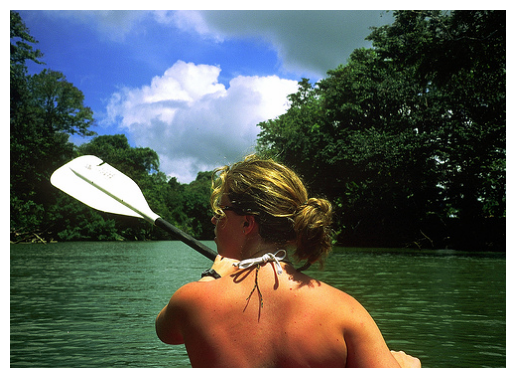

Top captions:
- a girl is rowing in a lake .
- girl in a thin rowboat leaving the dock of a lake .
- a woman paddles a boat down a river .
- person standing in the water by a yellow boat with an oar in their hand .
- a person paddles a boat on a lake .
- a person swimming in a pretty lake with a waterfall in the background
- a girl whipping water from her hair in a lake
- a person swims in a body of water with a waterfall .
- a man is standing in the water with a kayak .
- person canoes in lake .
- a person rows a boat over a large body of water .
- a person waterskiing in a river with a large wall in the background .
- a woman in a river is shaking her hair causing a water to spray everywhere .
- a person standing on a frozen lake .
- a man on a fishing boat pushing a wooden pole into the water .
- a couple standing on the deck of a boat watching the water .
- this is a boat on the water with mountains in the background .
- a woman kayaking down a river .
- the little girl is wearing 

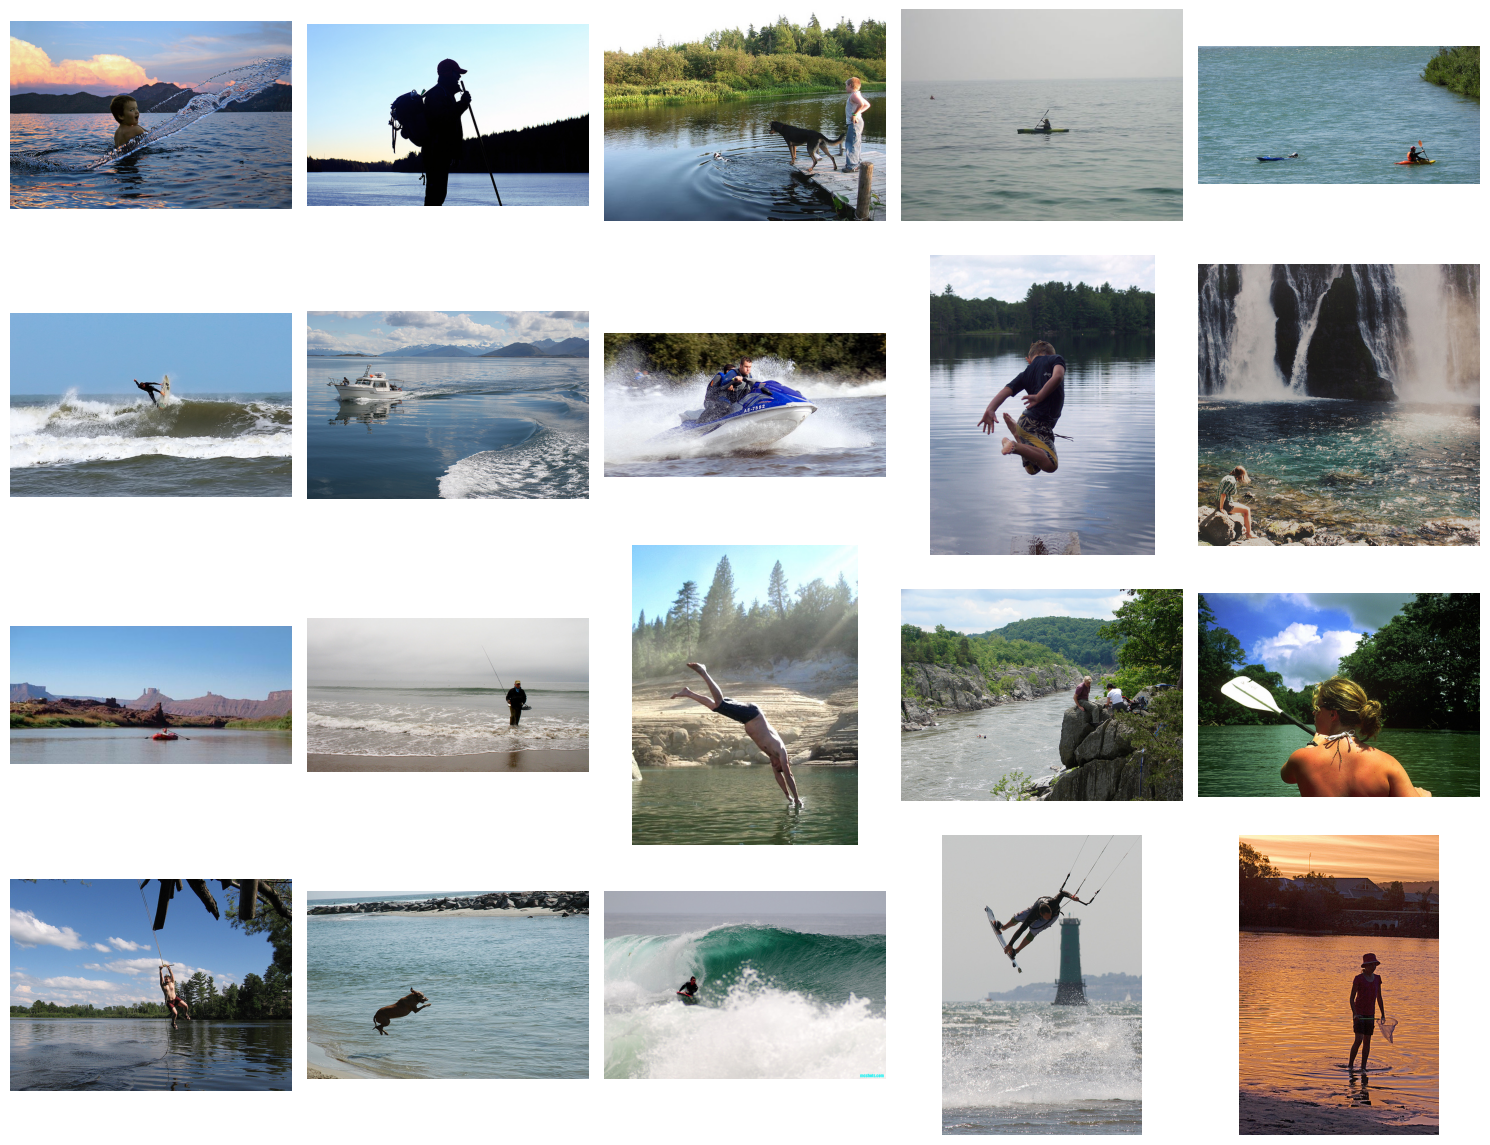

In [ ]:
def show_image_to_text(image_idx, top_k=5):
    topk = (unique_img_embs[image_idx] @ all_txt_embs.T).topk(top_k).indices
    plt.imshow(Image.open(f"Images/{unique_img_names[image_idx]}"))
    plt.axis("off")
    plt.show()
    print("Top captions:"); [print("-", all_caps[i]) for i in topk]

def show_text_to_image(caption_idx, top_k=20, imgs_per_row=5):
    topk = (all_txt_embs[caption_idx] @ unique_img_embs.T).topk(top_k).indices
    print("Query:", all_caps[caption_idx])

    rows = (top_k + imgs_per_row - 1) // imgs_per_row
    plt.figure(figsize=(imgs_per_row * 3, rows * 3))

    for i, idx in enumerate(topk):
        plt.subplot(rows, imgs_per_row, i + 1)
        plt.imshow(Image.open(f"Images/{unique_img_names[idx]}"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_image_to_text(6, top_k=20)
show_text_to_image(6, top_k=20)

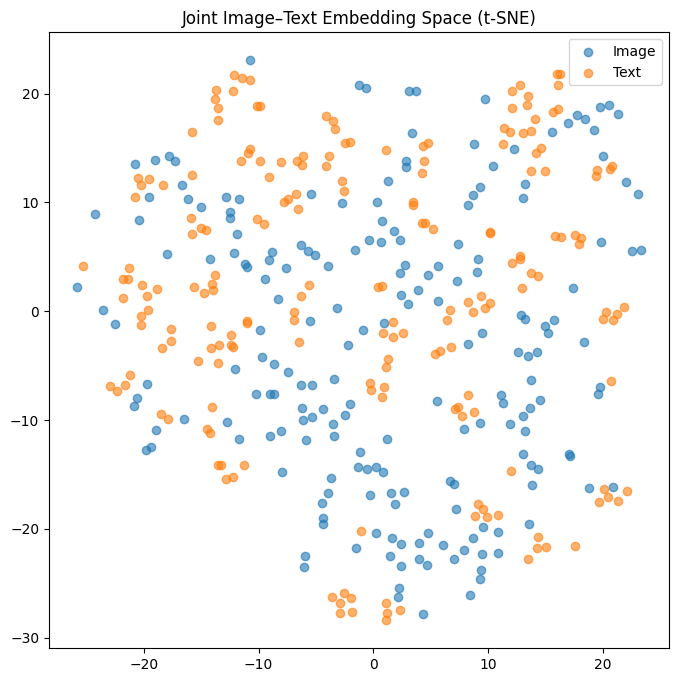

In [12]:
n = min(200, len(unique_img_embs), len(all_txt_embs))
X = np.vstack([unique_img_embs[:n].cpu().numpy(), all_txt_embs[:n].cpu().numpy()])
labels = ["Image"] * n + ["Text"] * n
X_2d = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42).fit_transform(X)

plt.figure(figsize=(8, 8))
for lab in ["Image", "Text"]:
    idx = [i for i, l in enumerate(labels) if l == lab]
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=lab, alpha=0.6)
plt.legend()
plt.title("Joint Image–Text Embedding Space (t-SNE)")
plt.savefig("results/03_tsne.png")
plt.show()